In [ ]:
# @title Configuración inicial del notebook
# Ejecuta esta celda para configurar el entorno

import sys
print(f"Python version: {sys.version}")

# Instalar paquetes necesarios (descomentar si es necesario)
# !pip install kagglehub pandas numpy scikit-learn imbalanced-learn xgboost shap matplotlib seaborn

# Importar todas las librerías
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Configurar visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print(" Librerías cargadas correctamente")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
✅ Librerías cargadas correctamente


In [ ]:
# @title Descargar dataset desde Kaggle usando kagglehub

print("=" * 60)
print("DESCARGANDO DATASET DESDE KAGGLE")
print("=" * 60)

try:
    # Descargar la última versión del dataset
    path = kagglehub.dataset_download("thedevastator/higher-education-predictors-of-student-retention")
    print(f" Datos descargados exitosamente en: {path}")

    # Buscar el archivo CSV
    csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

    if len(csv_files) == 0:
        raise FileNotFoundError("No se encontró archivo CSV en la descarga")

    csv_path = os.path.join(path, csv_files[0])
    print(f" Archivo encontrado: {csv_files[0]}")

    # Cargar datos
    df = pd.read_csv(csv_path)
    print(f" Datos cargados: {df.shape[0]} filas, {df.shape[1]} columnas")

except Exception as e:
    print(f" Error al descargar/cargar datos: {e}")
    print("  Asegúrate de tener conexión a Internet y kagglehub instalado")

DESCARGANDO DATASET DESDE KAGGLE
Using Colab cache for faster access to the 'higher-education-predictors-of-student-retention' dataset.
✅ Datos descargados exitosamente en: /kaggle/input/higher-education-predictors-of-student-retention
📄 Archivo encontrado: dataset.csv
✅ Datos cargados: 4424 filas, 35 columnas


In [ ]:
# @title Visualizar primeras filas del dataset

print("=" * 60)
print("PRIMERAS 5 FILAS DEL DATASET")
print("=" * 60)
display(df.head())

PRIMERAS 5 FILAS DEL DATASET


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
# @title Información general del dataset

print("=" * 60)
print("INFORMACIÓN DEL DATASET")
print("=" * 60)

print("\n Tipos de datos y valores nulos:")
df.info()

print("\n Estadísticas descriptivas:")
display(df.describe())

INFORMACIÓN DEL DATASET

📊 Tipos de datos y valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-nu

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [ ]:
# @title Análisis de valores nulos y variable objetivo

print("=" * 60)
print("ANÁLISIS DE VALORES NULOS")
print("=" * 60)

nulos = df.isnull().sum()
nulos = nulos[nulos > 0]
if len(nulos) > 0:
    print(nulos)
else:
    print(" No hay valores nulos en el dataset")

print("\n" + "=" * 60)
print("VARIABLE OBJETIVO (TARGET)")
print("=" * 60)

# Identificar variable objetivo
if 'Target' in df.columns:
    print(df['Target'].value_counts())
    print(f"\n Proporciones:")
    print(df['Target'].value_counts(normalize=True) * 100)
else:
    print("  Columnas disponibles:", df.columns.tolist())

ANÁLISIS DE VALORES NULOS
✅ No hay valores nulos en el dataset

VARIABLE OBJETIVO (TARGET)
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

📊 Proporciones:
Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


CREANDO VARIABLE OBJETIVO BINARIA
✅ Variable objetivo 'deserta' creada
   - Desertores (1): 1421
   - No desertores (0): 3003
   - Tasa de deserción: 32.12%


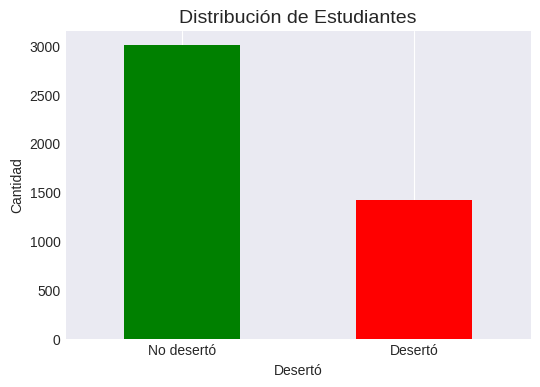

In [ ]:
# @title Crear variable objetivo binaria

print("=" * 60)
print("CREANDO VARIABLE OBJETIVO BINARIA")
print("=" * 60)

# Crear variable binaria: 1 = Dropout (desertó), 0 = otros casos
if 'Target' in df.columns:
    df['deserta'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)
else:
    # Buscar columna similar
    target_col = [col for col in df.columns if 'target' in col.lower() or 'dropout' in col.lower()]
    if target_col:
        df['deserta'] = df[target_col[0]].apply(lambda x: 1 if str(x).lower() == 'dropout' else 0)

print(f" Variable objetivo 'deserta' creada")
print(f"   - Desertores (1): {df['deserta'].sum()}")
print(f"   - No desertores (0): {len(df) - df['deserta'].sum()}")
print(f"   - Tasa de deserción: {df['deserta'].mean()*100:.2f}%")

# Visualizar distribución
plt.figure(figsize=(6, 4))
df['deserta'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribución de Estudiantes', fontsize=14)
plt.xlabel('Desertó')
plt.ylabel('Cantidad')
plt.xticks([0, 1], ['No desertó', 'Desertó'], rotation=0)
plt.grid(axis='y')
plt.show()

In [ ]:
# @title Eliminar columnas con leakage y separar variables

print("=" * 60)
print("ELIMINANDO COLUMNAS CON LEAKAGE")
print("=" * 60)

# Identificar columnas que causarían leakage
columnas_leakage = []
for col in df.columns:
    col_lower = col.lower()
    keywords = ['grade', 'score', 'semester_2', 'semester2', 'final', 'sem_2']
    if any(keyword in col_lower for keyword in keywords):
        if col not in ['deserta', 'Target']:
            columnas_leakage.append(col)

if columnas_leakage:
    print(f"  Eliminando: {columnas_leakage}")
    df = df.drop(columns=columnas_leakage)
else:
    print(" No se encontraron columnas con leakage evidente")

# Separar X e y
X = df.drop(['deserta', 'Target'], axis=1, errors='ignore')
y = df['deserta']

print(f"\n Predictores (X): {X.shape[1]} variables")
print(f" Variable objetivo (y): {y.shape[0]} registros")

ELIMINANDO COLUMNAS CON LEAKAGE
⚠️  Eliminando: ['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']

✅ Predictores (X): 32 variables
✅ Variable objetivo (y): 4424 registros


In [ ]:
# @title Manejo de valores nulos

print("=" * 60)
print("TRATAMIENTO DE VALORES NULOS")
print("=" * 60)

nulos_antes = X.isnull().sum().sum()
print(f"Valores nulos antes: {nulos_antes}")

for col in X.columns:
    if X[col].isnull().sum() > 0:
        if X[col].dtype in ['int64', 'float64']:
            X[col].fillna(X[col].median(), inplace=True)
            print(f"   - {col}: rellenados con mediana")
        else:
            X[col].fillna(X[col].mode()[0], inplace=True)
            print(f"   - {col}: rellenados con moda")

print(f"\n Valores nulos después: {X.isnull().sum().sum()}")

TRATAMIENTO DE VALORES NULOS
Valores nulos antes: 0

✅ Valores nulos después: 0


In [ ]:
# @title Codificación one-hot y escalado

from sklearn.preprocessing import MinMaxScaler

print("=" * 60)
print("CODIFICACIÓN ONE-HOT Y ESCALADO")
print("=" * 60)

# One-hot encoding
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"📋 Variables categóricas: {categorical_cols}")

if categorical_cols:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    print(f" Dimensiones después de one-hot: {X.shape}")
else:
    print(" No hay variables categóricas que codificar")

# Escalado Min-Max
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
scaler = MinMaxScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
print(f" {len(numeric_cols)} variables numéricas escaladas (Min-Max)")

CODIFICACIÓN ONE-HOT Y ESCALADO
📋 Variables categóricas: []
✅ No hay variables categóricas que codificar
✅ 32 variables numéricas escaladas (Min-Max)


MANEJO DE DESBALANCE CON SMOTE
📊 Distribución original:
deserta
0    3003
1    1421
Name: count, dtype: int64

📊 Distribución después de SMOTE:
deserta
1    3003
0    3003
Name: count, dtype: int64


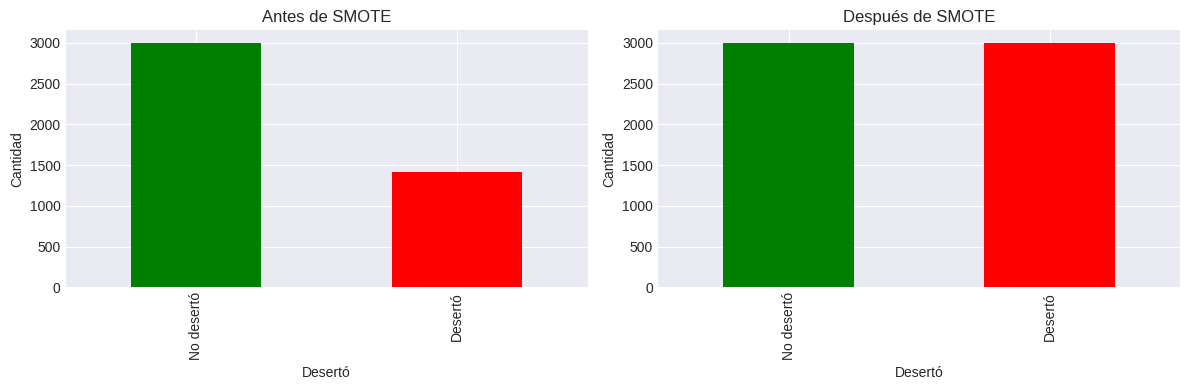

In [ ]:
# @title Manejo de desbalance con SMOTE

from imblearn.over_sampling import SMOTE

print("=" * 60)
print("MANEJO DE DESBALANCE CON SMOTE")
print("=" * 60)

print(" Distribución original:")
print(y.value_counts())

# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\n Distribución después de SMOTE:")
print(pd.Series(y_resampled).value_counts())

# Visualizar balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Antes
y.value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Antes de SMOTE')
axes[0].set_xlabel('Desertó')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No desertó', 'Desertó'])

# Después
pd.Series(y_resampled).value_counts().plot(kind='bar', ax=axes[1], color=['green', 'red'])
axes[1].set_title('Después de SMOTE')
axes[1].set_xlabel('Desertó')
axes[1].set_ylabel('Cantidad')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No desertó', 'Desertó'])

plt.tight_layout()
plt.show()

In [ ]:
# @title División entrenamiento (70%), validación (15%), prueba (15%)

from sklearn.model_selection import train_test_split

print("=" * 60)
print("DIVISIÓN DE DATOS")
print("=" * 60)

# Primera división: 70% entrenamiento, 30% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X_resampled, y_resampled, test_size=0.30, random_state=42, stratify=y_resampled
)

# Segunda división: 50% del temporal = 15% validación, 50% = 15% prueba
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f" Entrenamiento: {X_train.shape[0]} registros ({X_train.shape[0]/len(y_resampled)*100:.0f}%)")
print(f" Validación: {X_val.shape[0]} registros ({X_val.shape[0]/len(y_resampled)*100:.0f}%)")
print(f" Prueba: {X_test.shape[0]} registros ({X_test.shape[0]/len(y_resampled)*100:.0f}%)")

print(f"\n Distribución en entrenamiento:")
print(pd.Series(y_train).value_counts())

DIVISIÓN DE DATOS
✅ Entrenamiento: 4204 registros (70%)
✅ Validación: 901 registros (15%)
✅ Prueba: 901 registros (15%)

📊 Distribución en entrenamiento:
deserta
1    2102
0    2102
Name: count, dtype: int64


In [ ]:
# @title Definir y entrenar modelos

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("=" * 60)
print("ENTRENAMIENTO DE MODELOS")
print("=" * 60)

# Definir modelos
modelos = {
    'Regresión Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Árbol de Decisión (CART)': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Entrenar cada modelo
modelos_entrenados = {}
for nombre, modelo in modelos.items():
    print(f"\n Entrenando {nombre}...")
    modelo.fit(X_train, y_train)
    modelos_entrenados[nombre] = modelo
    print(f"    Modelo listo")

ENTRENAMIENTO DE MODELOS

📊 Entrenando Regresión Logística...
   ✅ Modelo listo

📊 Entrenando Árbol de Decisión (CART)...
   ✅ Modelo listo

📊 Entrenando Random Forest...
   ✅ Modelo listo

📊 Entrenando XGBoost...
   ✅ Modelo listo


In [ ]:
# @title Validación cruzada estratificada (5 folds)

from sklearn.model_selection import StratifiedKFold, cross_val_score

print("=" * 60)
print("VALIDACIÓN CRUZADA ESTRATIFICADA (5 FOLDS)")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_cv = []

for nombre, modelo in modelos_entrenados.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='roc_auc')
    resultados_cv.append({
        'Modelo': nombre,
        'AUC promedio': scores.mean(),
        'Desv. estándar': scores.std()
    })
    print(f"\n{nombre}:")
    print(f"   AUC promedio: {scores.mean():.4f}")
    print(f"   Desv. estándar: {scores.std():.4f}")

df_cv = pd.DataFrame(resultados_cv)
print("\n RESUMEN VALIDACIÓN CRUZADA:")
print(df_cv.to_string(index=False))

VALIDACIÓN CRUZADA ESTRATIFICADA (5 FOLDS)

Regresión Logística:
   AUC promedio: 0.9259
   Desv. estándar: 0.0107

Árbol de Decisión (CART):
   AUC promedio: 0.8700
   Desv. estándar: 0.0078

Random Forest:
   AUC promedio: 0.9578
   Desv. estándar: 0.0061

XGBoost:
   AUC promedio: 0.9576
   Desv. estándar: 0.0038

📊 RESUMEN VALIDACIÓN CRUZADA:
                  Modelo  AUC promedio  Desv. estándar
     Regresión Logística      0.925914        0.010705
Árbol de Decisión (CART)      0.870018        0.007813
           Random Forest      0.957807        0.006072
                 XGBoost      0.957607        0.003822


In [ ]:
# @title Evaluar modelos en conjunto de validación

from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)

print("=" * 60)
print("EVALUACIÓN DE MODELOS")
print("=" * 60)

resultados = []

for nombre, modelo in modelos_entrenados.items():
    y_pred = modelo.predict(X_val)
    y_proba = modelo.predict_proba(X_val)[:, 1]

    resultados.append({
        'Modelo': nombre,
        'Precisión': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1-Score': f1_score(y_val, y_pred),
        'AUC-ROC': roc_auc_score(y_val, y_proba)
    })

    print(f"\n--- {nombre} ---")
    print(f"  Precisión: {precision_score(y_val, y_pred):.4f}")
    print(f"  Recall: {recall_score(y_val, y_pred):.4f}")
    print(f"  F1-Score: {f1_score(y_val, y_pred):.4f}")
    print(f"  AUC-ROC: {roc_auc_score(y_val, y_proba):.4f}")
    print(f"\n  Matriz de confusión:")
    print(pd.DataFrame(confusion_matrix(y_val, y_pred),
                       index=['Real: No desertó', 'Real: Desertó'],
                       columns=['Pred: No desertó', 'Pred: Desertó']))

# Tabla comparativa
df_resultados = pd.DataFrame(resultados)
print("\n" + "=" * 60)
print(" TABLA COMPARATIVA DE MODELOS")
print("=" * 60)
print(df_resultados.to_string(index=False))

EVALUACIÓN DE MODELOS

--- Regresión Logística ---
  Precisión: 0.8846
  Recall: 0.8160
  F1-Score: 0.8489
  AUC-ROC: 0.9265

  Matriz de confusión:
                  Pred: No desertó  Pred: Desertó
Real: No desertó               402             48
Real: Desertó                   83            368

--- Árbol de Decisión (CART) ---
  Precisión: 0.9066
  Recall: 0.8182
  F1-Score: 0.8601
  AUC-ROC: 0.8937

  Matriz de confusión:
                  Pred: No desertó  Pred: Desertó
Real: No desertó               412             38
Real: Desertó                   82            369

--- Random Forest ---
  Precisión: 0.9167
  Recall: 0.8780
  F1-Score: 0.8969
  AUC-ROC: 0.9625

  Matriz de confusión:
                  Pred: No desertó  Pred: Desertó
Real: No desertó               414             36
Real: Desertó                   55            396

--- XGBoost ---
  Precisión: 0.9194
  Recall: 0.8847
  F1-Score: 0.9017
  AUC-ROC: 0.9621

  Matriz de confusión:
                  Pred: No desert

In [ ]:
# @title Optimizar umbral (Recall con precisión ≥ 60%)

def encontrar_mejor_umbral(modelo, X_val, y_val):
    y_proba = modelo.predict_proba(X_val)[:, 1]
    umbrales = np.arange(0.1, 0.9, 0.05)

    mejor_recall = 0
    mejor_umbral = 0.5
    mejor_precision = 0

    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        precision = precision_score(y_val, y_pred, zero_division=0)
        recall = recall_score(y_val, y_pred, zero_division=0)

        if precision >= 0.60 and recall > mejor_recall:
            mejor_recall = recall
            mejor_umbral = umbral
            mejor_precision = precision

    return mejor_umbral, mejor_recall, mejor_precision

print("=" * 60)
print("SELECCIÓN DEL MEJOR MODELO (Recall con Precisión ≥ 60%)")
print("=" * 60)

mejor_modelo_nombre = None
mejor_modelo_obj = None
mejor_umbral_global = 0.5
mejor_recall_global = 0

for nombre, modelo in modelos_entrenados.items():
    umbral, recall, precision = encontrar_mejor_umbral(modelo, X_val, y_val)
    print(f"\n{nombre}:")
    print(f"   Mejor umbral: {umbral}")
    print(f"   Recall alcanzado: {recall:.4f}")
    print(f"   Precisión alcanzada: {precision:.4f}")

    if recall > mejor_recall_global:
        mejor_recall_global = recall
        mejor_modelo_nombre = nombre
        mejor_modelo_obj = modelo
        mejor_umbral_global = umbral

print("\n" + "=" * 60)
print(f"🏆 MEJOR MODELO SELECCIONADO: {mejor_modelo_nombre}")
print(f"   Umbral óptimo: {mejor_umbral_global}")
print(f"   Recall: {mejor_recall_global:.4f}")
print("=" * 60)

SELECCIÓN DEL MEJOR MODELO (Recall con Precisión ≥ 60%)

Regresión Logística:
   Mejor umbral: 0.1
   Recall alcanzado: 0.9800
   Precisión alcanzada: 0.6088

Árbol de Decisión (CART):
   Mejor umbral: 0.1
   Recall alcanzado: 0.9047
   Precisión alcanzada: 0.7801

Random Forest:
   Mejor umbral: 0.1
   Recall alcanzado: 0.9956
   Precisión alcanzada: 0.6351

XGBoost:
   Mejor umbral: 0.1
   Recall alcanzado: 0.9534
   Precisión alcanzada: 0.8068

🏆 MEJOR MODELO SELECCIONADO: Random Forest
   Umbral óptimo: 0.1
   Recall: 0.9956


CURVAS ROC Y GANANCIA ACUMULADA


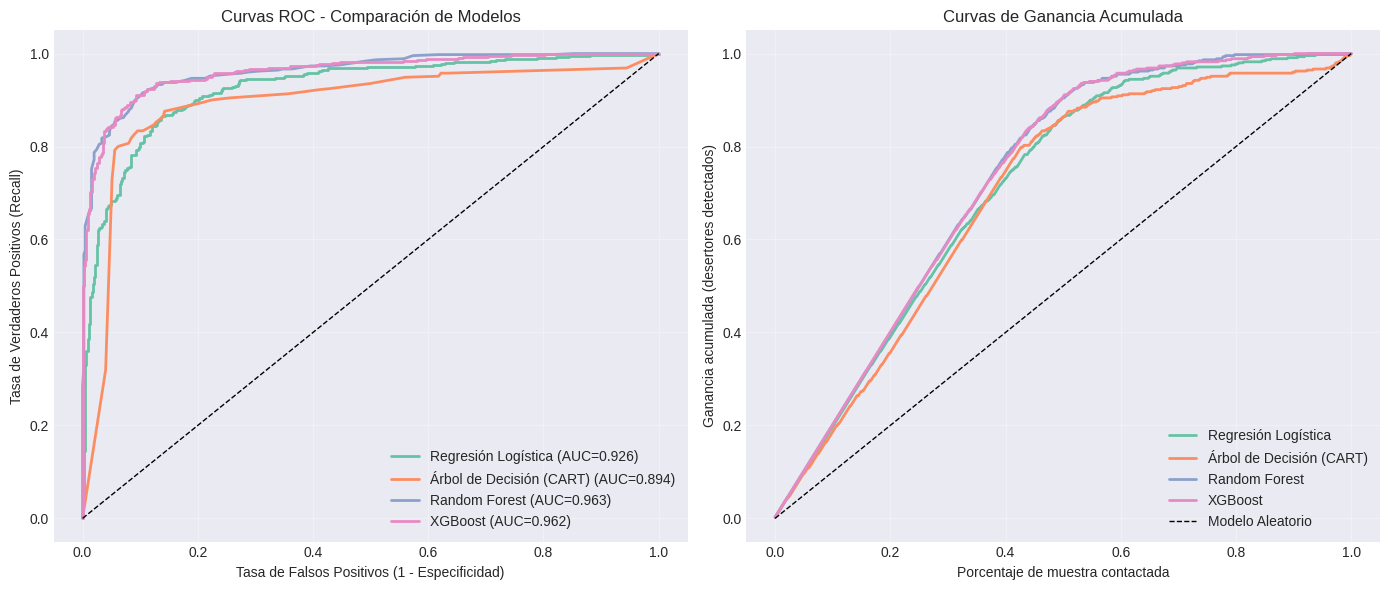

In [ ]:
# @title Curvas ROC y curvas de ganancia acumulada

from sklearn.metrics import roc_curve, roc_auc_score

print("=" * 60)
print("CURVAS ROC Y GANANCIA ACUMULADA")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Curvas ROC
for nombre, modelo in modelos_entrenados.items():
    y_proba = modelo.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc = roc_auc_score(y_val, y_proba)
    axes[0].plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[0].set_title('Curvas ROC - Comparación de Modelos')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Curvas de ganancia acumulada
for nombre, modelo in modelos_entrenados.items():
    y_proba = modelo.predict_proba(X_val)[:, 1]
    sorted_idx = np.argsort(y_proba)[::-1]
    ganancia = np.cumsum(y_val.iloc[sorted_idx]) / np.sum(y_val)
    axes[1].plot(np.linspace(0, 1, len(ganancia)), ganancia, label=nombre, linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Modelo Aleatorio')
axes[1].set_xlabel('Porcentaje de muestra contactada')
axes[1].set_ylabel('Ganancia acumulada (desertores detectados)')
axes[1].set_title('Curvas de Ganancia Acumulada')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

EVALUACIÓN DEL MEJOR MODELO (Random Forest) EN PRUEBA

📊 Métricas en conjunto de prueba (umbral = 0.1):
   Precisión: 0.6203
   Recall: 0.9911
   F1-Score: 0.7630
   AUC-ROC: 0.9637

📊 Matriz de confusión en prueba:
                  Pred: No desertó  Pred: Desertó
Real: No desertó               178            273
Real: Desertó                    4            446


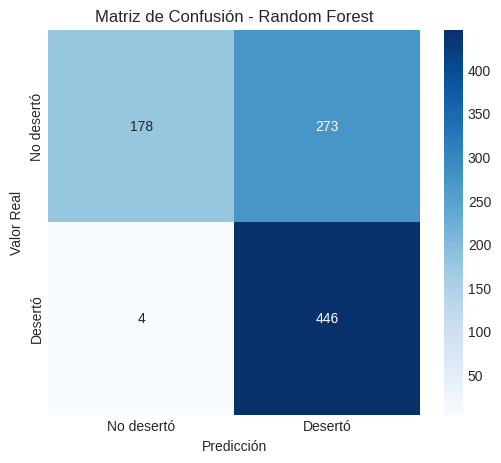

In [ ]:
# @title Evaluar mejor modelo en conjunto de prueba

print("=" * 60)
print(f"EVALUACIÓN DEL MEJOR MODELO ({mejor_modelo_nombre}) EN PRUEBA")
print("=" * 60)

# Usar el umbral óptimo encontrado
y_proba_test = mejor_modelo_obj.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= mejor_umbral_global).astype(int)

print(f"\n Métricas en conjunto de prueba (umbral = {mejor_umbral_global}):")
print(f"   Precisión: {precision_score(y_test, y_pred_test):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_test):.4f}")
print(f"   F1-Score: {f1_score(y_test, y_pred_test):.4f}")
print(f"   AUC-ROC: {roc_auc_score(y_test, y_proba_test):.4f}")

print(f"\n Matriz de confusión en prueba:")
cm_test = confusion_matrix(y_test, y_pred_test)
cm_df = pd.DataFrame(cm_test,
                     index=['Real: No desertó', 'Real: Desertó'],
                     columns=['Pred: No desertó', 'Pred: Desertó'])
print(cm_df)

# Visualizar matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No desertó', 'Desertó'],
            yticklabels=['No desertó', 'Desertó'])
plt.title(f'Matriz de Confusión - {mejor_modelo_nombre}')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

IMPORTANCIA DE VARIABLES - Random Forest


<Figure size 1000x800 with 0 Axes>

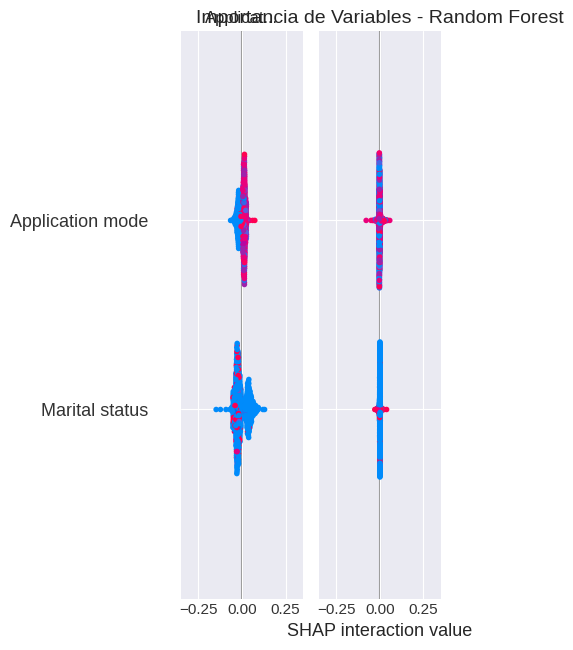

<Figure size 1200x800 with 0 Axes>

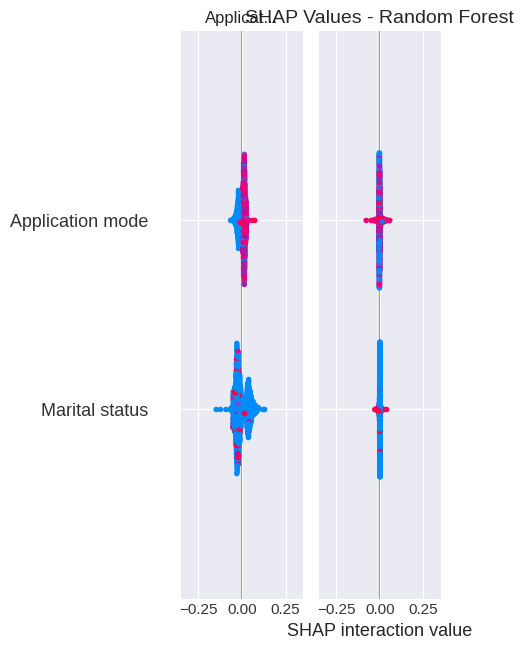


📊 TOP 10 VARIABLES MÁS IMPORTANTES:
                              Variable  Importancia
   Curricular units 2nd sem (approved)     0.216284
   Curricular units 1st sem (approved)     0.150601
               Tuition fees up to date     0.068533
Curricular units 2nd sem (evaluations)     0.060560
                     Age at enrollment     0.052943
Curricular units 1st sem (evaluations)     0.041126
                                Course     0.036088
   Curricular units 2nd sem (enrolled)     0.033096
                   Father's occupation     0.030238
                   Mother's occupation     0.029129


In [ ]:
# @title Interpretación del modelo con SHAP values

import shap

print("=" * 60)
print(f"IMPORTANCIA DE VARIABLES - {mejor_modelo_nombre}")
print("=" * 60)

# Crear explainer según el tipo de modelo
if 'XGBoost' in mejor_modelo_nombre or 'Random Forest' in mejor_modelo_nombre or 'Árbol' in mejor_modelo_nombre:
    # Modelos basados en árboles
    explainer = shap.TreeExplainer(mejor_modelo_obj)
    shap_values = explainer.shap_values(X_test)

    # Gráfico de importancia global (barras)
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    plt.title(f'Importancia de Variables - {mejor_modelo_nombre}', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Gráfico detallado (beeswarm)
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title(f'SHAP Values - {mejor_modelo_nombre}', fontsize=14)
    plt.tight_layout()
    plt.show()

elif 'Logística' in mejor_modelo_nombre:
    # Regresión Logística
    explainer = shap.LinearExplainer(mejor_modelo_obj, X_train)
    shap_values = explainer.shap_values(X_test)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    plt.title(f'Importancia de Variables - {mejor_modelo_nombre}', fontsize=14)
    plt.tight_layout()
    plt.show()

else:
    print("  SHAP no disponible para este tipo de modelo")

# Mostrar top 10 variables más importantes
if hasattr(mejor_modelo_obj, 'feature_importances_'):
    importancia = pd.DataFrame({
        'Variable': X.columns,
        'Importancia': mejor_modelo_obj.feature_importances_
    }).sort_values('Importancia', ascending=False).head(10)

    print("\n TOP 10 VARIABLES MÁS IMPORTANTES:")
    print(importancia.to_string(index=False))

In [ ]:
# @title Tabla resumen de todos los modelos

print("=" * 60)
print("RESUMEN FINAL DE RESULTADOS")
print("=" * 60)

# Tabla comparativa completa
print("\n COMPARATIVA DE TODOS LOS MODELOS (Validación):")
print(df_resultados.to_string(index=False))

print("\n VALIDACIÓN CRUZADA (AUC-ROC):")
print(df_cv.to_string(index=False))

print("\n" + "=" * 60)
print("CONCLUSIONES DEL ESTUDIO")
print("=" * 60)

# Identificar mejor modelo por cada métrica
mejor_auc = df_resultados.loc[df_resultados['AUC-ROC'].idxmax()]
mejor_recall = df_resultados.loc[df_resultados['Recall'].idxmax()]
mejor_f1 = df_resultados.loc[df_resultados['F1-Score'].idxmax()]

print(f"""
 MEJOR MODELO POR AUC-ROC: {mejor_auc['Modelo']} ({mejor_auc['AUC-ROC']:.4f})
 MEJOR MODELO POR RECALL: {mejor_recall['Modelo']} ({mejor_recall['Recall']:.4f})
 MEJOR MODELO POR F1-SCORE: {mejor_f1['Modelo']} ({mejor_f1['F1-Score']:.4f})
 MODELO SELECCIONADO PARA PRODUCCIÓN: {mejor_modelo_nombre}

 RECOMENDACIONES:
   1. El modelo {mejor_modelo_nombre} es el más adecuado para el sistema de alerta temprana
   2. Con un umbral de {mejor_umbral_global:.2f}, se detecta el {mejor_recall_global*100:.1f}% de los desertores
   3. Se debe implementar un dashboard con las top 10 variables más importantes
   4. Monitorear el modelo cada semestre para detectar cambios en el patrón de deserción
""")

RESUMEN FINAL DE RESULTADOS

📊 COMPARATIVA DE TODOS LOS MODELOS (Validación):
                  Modelo  Precisión   Recall  F1-Score  AUC-ROC
     Regresión Logística   0.884615 0.815965  0.848904 0.926494
Árbol de Decisión (CART)   0.906634 0.818182  0.860140 0.893695
           Random Forest   0.916667 0.878049  0.896942 0.962518
                 XGBoost   0.919355 0.884701  0.901695 0.962065

📊 VALIDACIÓN CRUZADA (AUC-ROC):
                  Modelo  AUC promedio  Desv. estándar
     Regresión Logística      0.925914        0.010705
Árbol de Decisión (CART)      0.870018        0.007813
           Random Forest      0.957807        0.006072
                 XGBoost      0.957607        0.003822

CONCLUSIONES DEL ESTUDIO

✅ MEJOR MODELO POR AUC-ROC: Random Forest (0.9625)
✅ MEJOR MODELO POR RECALL: XGBoost (0.8847)
✅ MEJOR MODELO POR F1-SCORE: XGBoost (0.9017)
✅ MODELO SELECCIONADO PARA PRODUCCIÓN: Random Forest

📌 RECOMENDACIONES:
   1. El modelo Random Forest es el más adecuado para

In [ ]:
# @title Guardar resultados en archivos CSV

print("=" * 60)
print("GUARDANDO RESULTADOS")
print("=" * 60)

# Guardar tabla de resultados
df_resultados.to_csv('resultados_modelos.csv', index=False)
print(" resultados_modelos.csv guardado")

# Guardar importancia de variables (si está disponible)
if 'importancia' in locals():
    importancia.to_csv('importancia_variables.csv', index=False)
    print(" importancia_variables.csv guardado")

# Guardar predicciones del mejor modelo en prueba
predicciones_df = pd.DataFrame({
    'real': y_test.values,
    'probabilidad_desercion': y_proba_test,
    'prediccion_umbral_optimo': y_pred_test
})
predicciones_df.to_csv('predicciones_prueba.csv', index=False)
print(" predicciones_prueba.csv guardado")

print("\n Todos los resultados han sido guardados exitosamente!")

GUARDANDO RESULTADOS
✅ resultados_modelos.csv guardado
✅ importancia_variables.csv guardado
✅ predicciones_prueba.csv guardado

✅ Todos los resultados han sido guardados exitosamente!


TOP 10 VARIABLES MÁS IMPORTANTES:
                              Variable  Importancia
   Curricular units 2nd sem (approved)     0.216284
   Curricular units 1st sem (approved)     0.150601
               Tuition fees up to date     0.068533
Curricular units 2nd sem (evaluations)     0.060560
                     Age at enrollment     0.052943
Curricular units 1st sem (evaluations)     0.041126
                                Course     0.036088
   Curricular units 2nd sem (enrolled)     0.033096
                   Father's occupation     0.030238
                   Mother's occupation     0.029129

✅ Gráfica guardada como 'importancia_variables_grande.png' (300 DPI)
✅ También guardada como 'importancia_variables_grande.pdf' (formato vectorial)


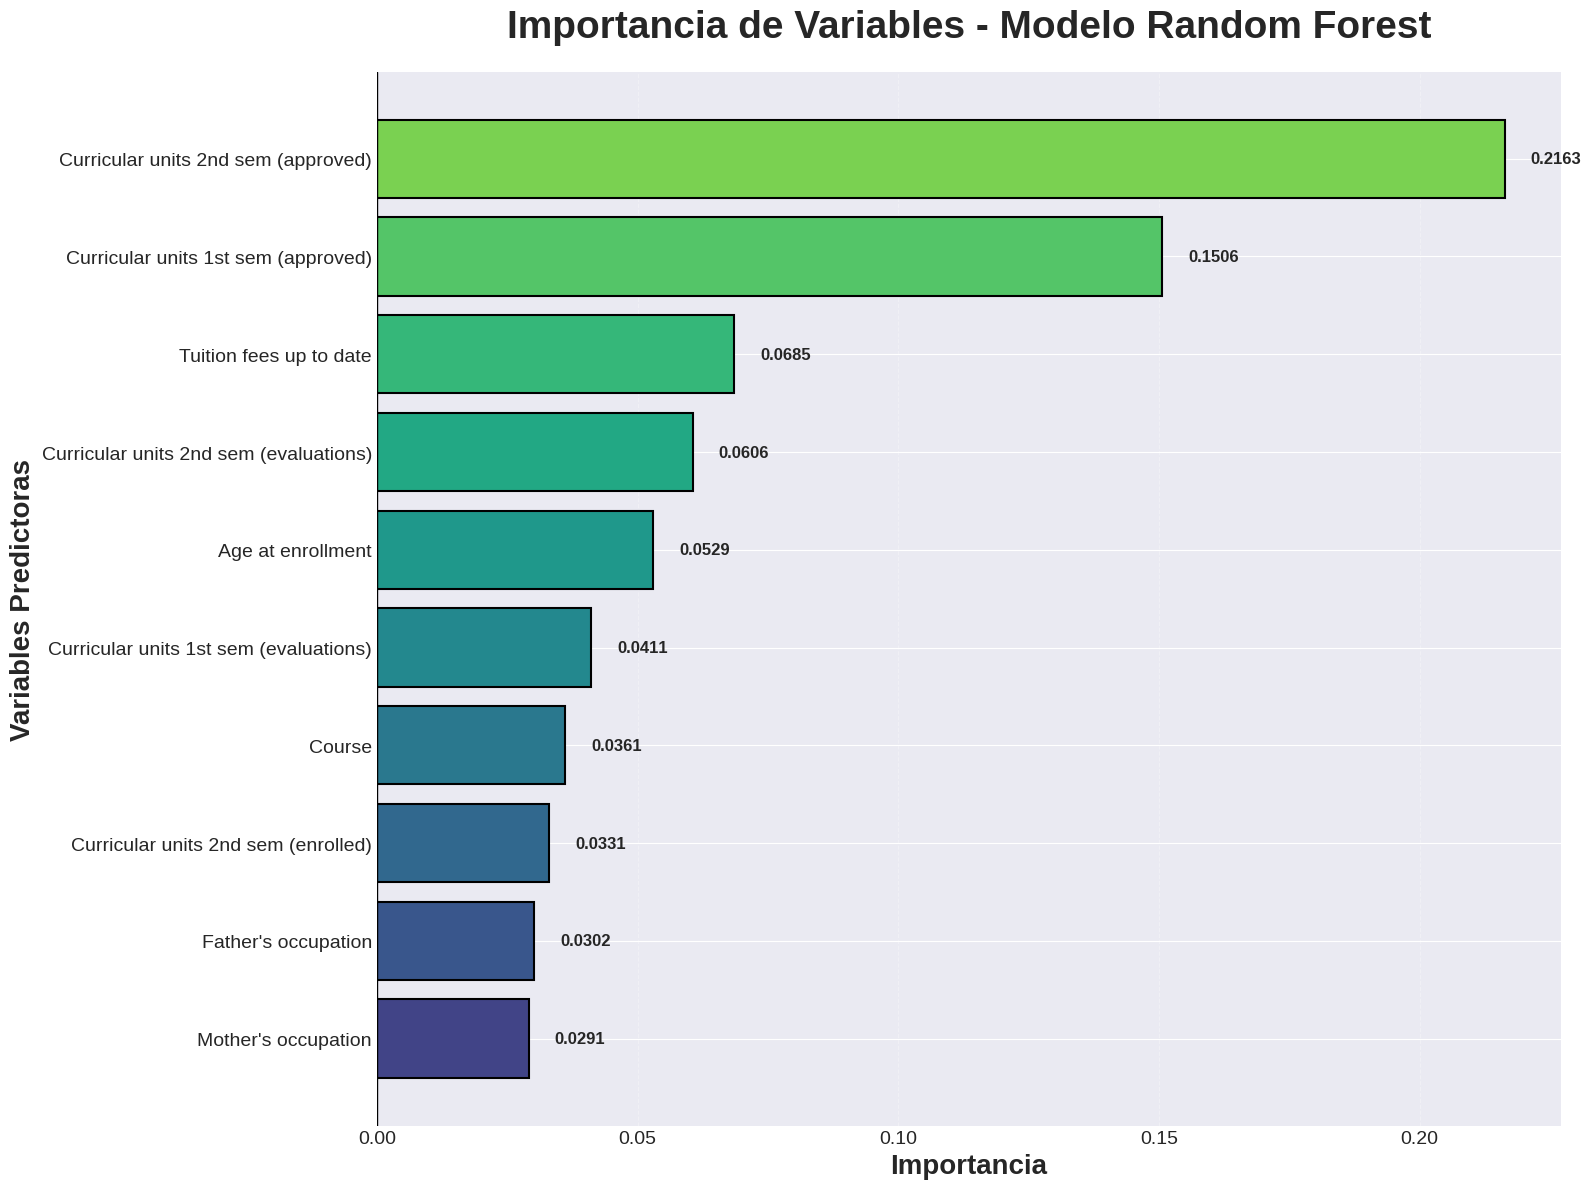

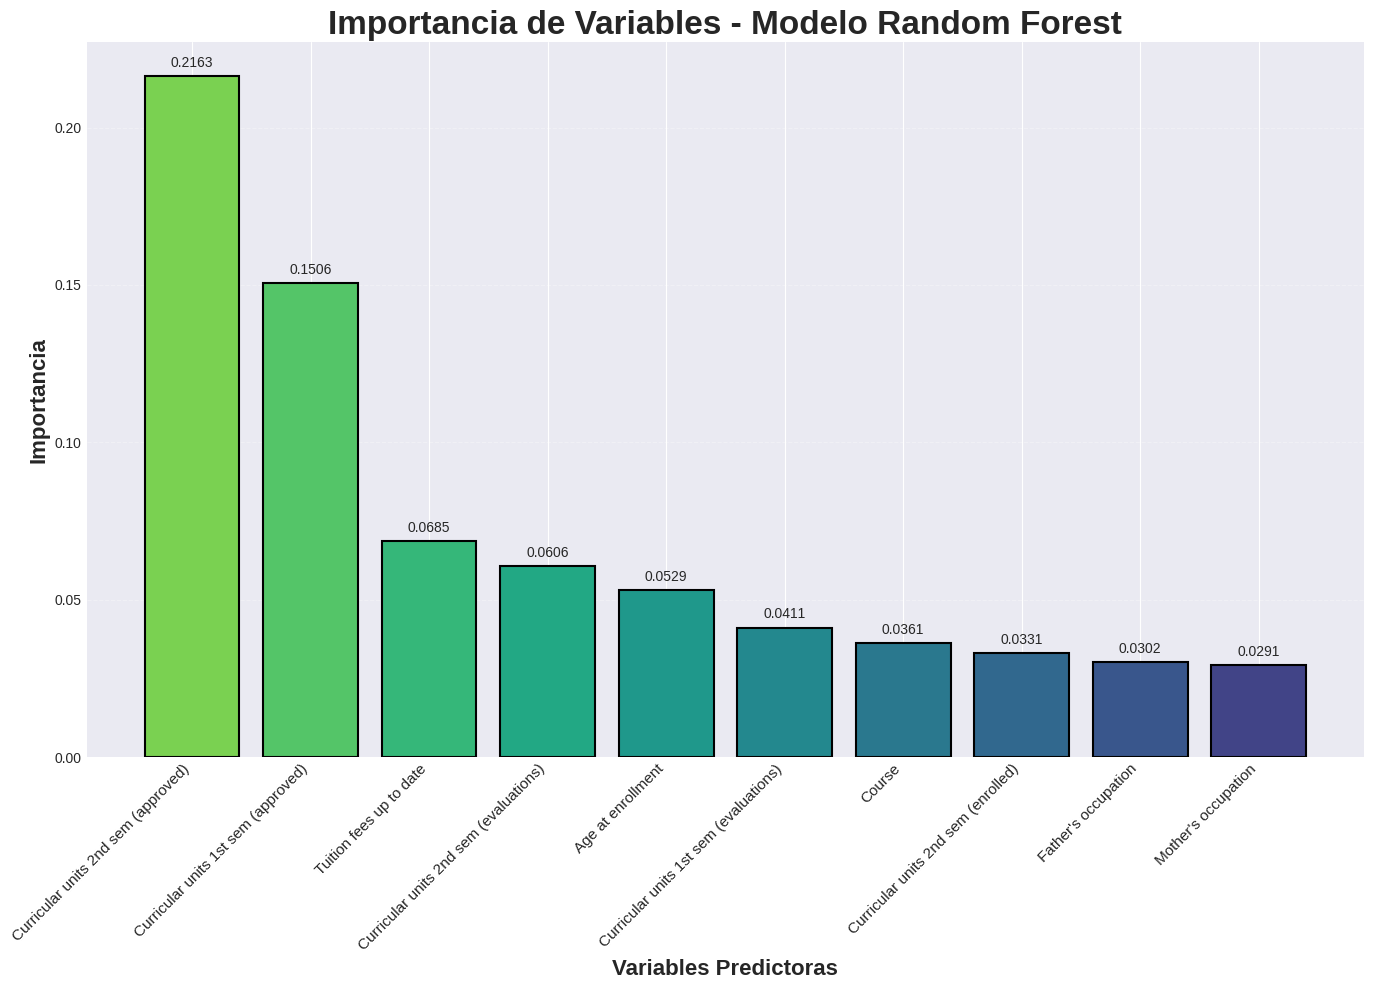


TABLA EN FORMATO LATEX PARA EL INFORME

\begin{table}[H]
\centering
\caption{Top 10 variables más importantes - Random Forest}
\label{tab:importancia}
\begin{tabular}{|l|c|}
\hline
\textbf{Variable} & \textbf{Importancia} \\
\hline
Curricular units 2nd sem (approved) & 0.2163 \\
Curricular units 1st sem (approved) & 0.1506 \\
Tuition fees up to date & 0.0685 \\
Curricular units 2nd sem (evaluations) & 0.0606 \\
Age at enrollment & 0.0529 \\
Curricular units 1st sem (evaluations) & 0.0411 \\
Course & 0.0361 \\
Curricular units 2nd sem (enrolled) & 0.0331 \\
Father's occupation & 0.0302 \\
Mother's occupation & 0.0291 \\
\hline
\end{tabular}
\end{table}


✅ Datos de importancia guardados en 'importancia_variables.csv'


In [ ]:
# =============================================================================
# SCRIPT PARA GENERAR GRÁFICA DE IMPORTANCIA DE VARIABLES - TAMAÑO GRANDE
# PROYECTO: Predicción de Deserción Estudiantil
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# =============================================================================
# 1. CARGAR DATOS (ejecuta esto después de tener X_train, y_train)
# =============================================================================

# Suponiendo que ya tienes X_train e y_train después de SMOTE
# Si no, ejecuta todo tu preprocesamiento primero

# Entrenar Random Forest (si no lo tienes entrenado)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Obtener importancia de variables
importancias = rf_model.feature_importances_
variables = X_train.columns

# Crear DataFrame
importancia_df = pd.DataFrame({
    'Variable': variables,
    'Importancia': importancias
}).sort_values('Importancia', ascending=False)

# Mostrar top 10
print("TOP 10 VARIABLES MÁS IMPORTANTES:")
print(importancia_df.head(10).to_string(index=False))

# =============================================================================
# 2. GENERAR GRÁFICA GRANDE Y PROFESIONAL
# =============================================================================

# Configurar estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# Crear figura más grande (tamaño 16x12 pulgadas)
fig, ax = plt.subplots(figsize=(16, 12))

# Colores degradados (más importante = más oscuro)
colors = plt.cm.viridis(np.linspace(0.8, 0.2, 10))

# Top 10 variables
top_10 = importancia_df.head(10)

# Barras horizontales
bars = ax.barh(top_10['Variable'], top_10['Importancia'], color=colors, edgecolor='black', linewidth=1.5)

# Invertir para que el más importante esté arriba
ax.invert_yaxis()

# Títulos y etiquetas con fuente más grande
ax.set_title('Importancia de Variables - Modelo Random Forest', fontsize=28, fontweight='bold', pad=25)
ax.set_xlabel('Importancia', fontsize=20, fontweight='bold')
ax.set_ylabel('Variables Predictoras', fontsize=20, fontweight='bold')

# Configurar tamaño de fuentes de los ejes
ax.tick_params(axis='both', labelsize=14)

# Añadir valores en las barras
for i, (bar, valor) in enumerate(zip(bars, top_10['Importancia'])):
    ax.text(valor + 0.005, bar.get_y() + bar.get_height()/2,
            f'{valor:.4f}',
            va='center', fontsize=12, fontweight='bold')

# Añadir línea vertical en 0
ax.axvline(x=0, color='black', linewidth=1)

# Añadir cuadrícula
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Ajustar layout
plt.tight_layout()

# Guardar imagen en alta resolución
plt.savefig('importancia_variables_grande.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('importancia_variables_grande.pdf', bbox_inches='tight', facecolor='white')

print("\n Gráfica guardada como 'importancia_variables_grande.png' (300 DPI)")
print("También guardada como 'importancia_variables_grande.pdf' (formato vectorial)")

plt.show()

# =============================================================================
# 3. GENERAR VERSIÓN HORIZONTAL ALTERNATIVA (BARRAS VERTICALES)
# =============================================================================

fig2, ax2 = plt.subplots(figsize=(14, 10))

# Barras verticales
x_pos = np.arange(len(top_10))
bars2 = ax2.bar(x_pos, top_10['Importancia'], color=colors, edgecolor='black', linewidth=1.5)

# Configurar etiquetas
ax2.set_xticks(x_pos)
ax2.set_xticklabels(top_10['Variable'], rotation=45, ha='right', fontsize=11)
ax2.set_title('Importancia de Variables - Modelo Random Forest', fontsize=24, fontweight='bold')
ax2.set_ylabel('Importancia', fontsize=16, fontweight='bold')
ax2.set_xlabel('Variables Predictoras', fontsize=16, fontweight='bold')

# Añadir valores
for bar, valor in zip(bars2, top_10['Importancia']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{valor:.4f}', ha='center', va='bottom', fontsize=10)

ax2.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('importancia_variables_vertical.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# 4. TABLA FORMATEADA PARA LATEX
# =============================================================================

print("\n" + "="*60)
print("TABLA EN FORMATO LATEX PARA EL INFORME")
print("="*60)

latex_table = """
\\begin{table}[H]
\\centering
\\caption{Top 10 variables más importantes - Random Forest}
\\label{tab:importancia}
\\begin{tabular}{|l|c|}
\\hline
\\textbf{Variable} & \\textbf{Importancia} \\\\
\\hline
"""

for _, row in top_10.iterrows():
    latex_table += f"{row['Variable']} & {row['Importancia']:.4f} \\\\\n"

latex_table += """\\hline
\\end{tabular}
\\end{table}
"""

print(latex_table)

# =============================================================================
# 5. GUARDAR DATOS DE IMPORTANCIA EN CSV
# =============================================================================

importancia_df.to_csv('importancia_variables.csv', index=False)
print("\n Datos de importancia guardados en 'importancia_variables.csv'")